# 流行効果付きSISモデルの解析

## 事前準備
 - 必要パッケージのインストール
 - グラフの調整
 - 関数の定義

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from typing import List, Tuple

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
# ========= ロード周り =========

def load_all_parts(max_filenum: int, pattern: str):
    
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"No files matched: {pattern}")

    c_list = lamb_values = None
    N = None
    k_ave = None
    gamma = None
    I_parts: List[np.ndarray] = []
    T_parts: List[np.ndarray] = []
    itr_ranges: List[Tuple[int, int]] = []

    loaded_file_num = 0
    for p in paths:
        d = np.load(p, allow_pickle=True)
        print(f"Loading file: {p}")
        if c_list is None:
            c_list = d["c_list"]
            lamb_values = d["lamb_values"]
            N = int(d["N"])
            k_ave = d["k_ave"]
            gamma = d["gamma"]
        else:
            # 一致性チェック（最低限）
            assert np.allclose(c_list, d["c_list"])
            assert np.allclose(lamb_values, d["lamb_values"])
        I_parts.append(d["I_all"])
        T_parts.append(d["times_all"])
        itr_ranges.append((int(d["itr_start"]), int(d["itr_end"])))
        loaded_file_num += 1

        if loaded_file_num >= max_filenum:
            break

    # itr 軸で連結
    I_all = np.concatenate(I_parts, axis=2)
    times_all = np.concatenate(T_parts, axis=2)

    return c_list, lamb_values, I_all, times_all, N, k_ave, gamma

In [3]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

In [4]:
c_list, lamb_values, I_all, times_all, N, k_ave, gamma = load_all_parts(20,"sis/rho0=1/N=4000/k_ave=16/*.npz")

print("")
print(f"k_ave: {k_ave:.2f}")
print(f"N: {N}")
print(f"gamma: {gamma:.2f}")
print(f"c_list: {c_list}")
print(f"lamb_values: {lamb_values}")
print(f"I_all shape: {I_all.shape}")
print(f"times_all shape: {times_all.shape}")

total_itr = len(times_all[0, 0, :])
print(f"total_itr: {total_itr}")

Loading file: sis/rho0=1/N=4000/k_ave=16/00.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/01.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/02.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/03.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/04.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/05.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/06.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/07.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/08.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/09.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/10.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/11.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/12.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/13.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/14.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/15.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/16.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/17.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/18.npz
Loading file: sis/rho0=1/N=4000/k_ave=16/19.npz

k_ave: 16.00
N: 4000
gamma: 1.00
c_list

## 統計的情報
 - イベント数分布
 - 時間発展
 - 終状態ヒストグラム

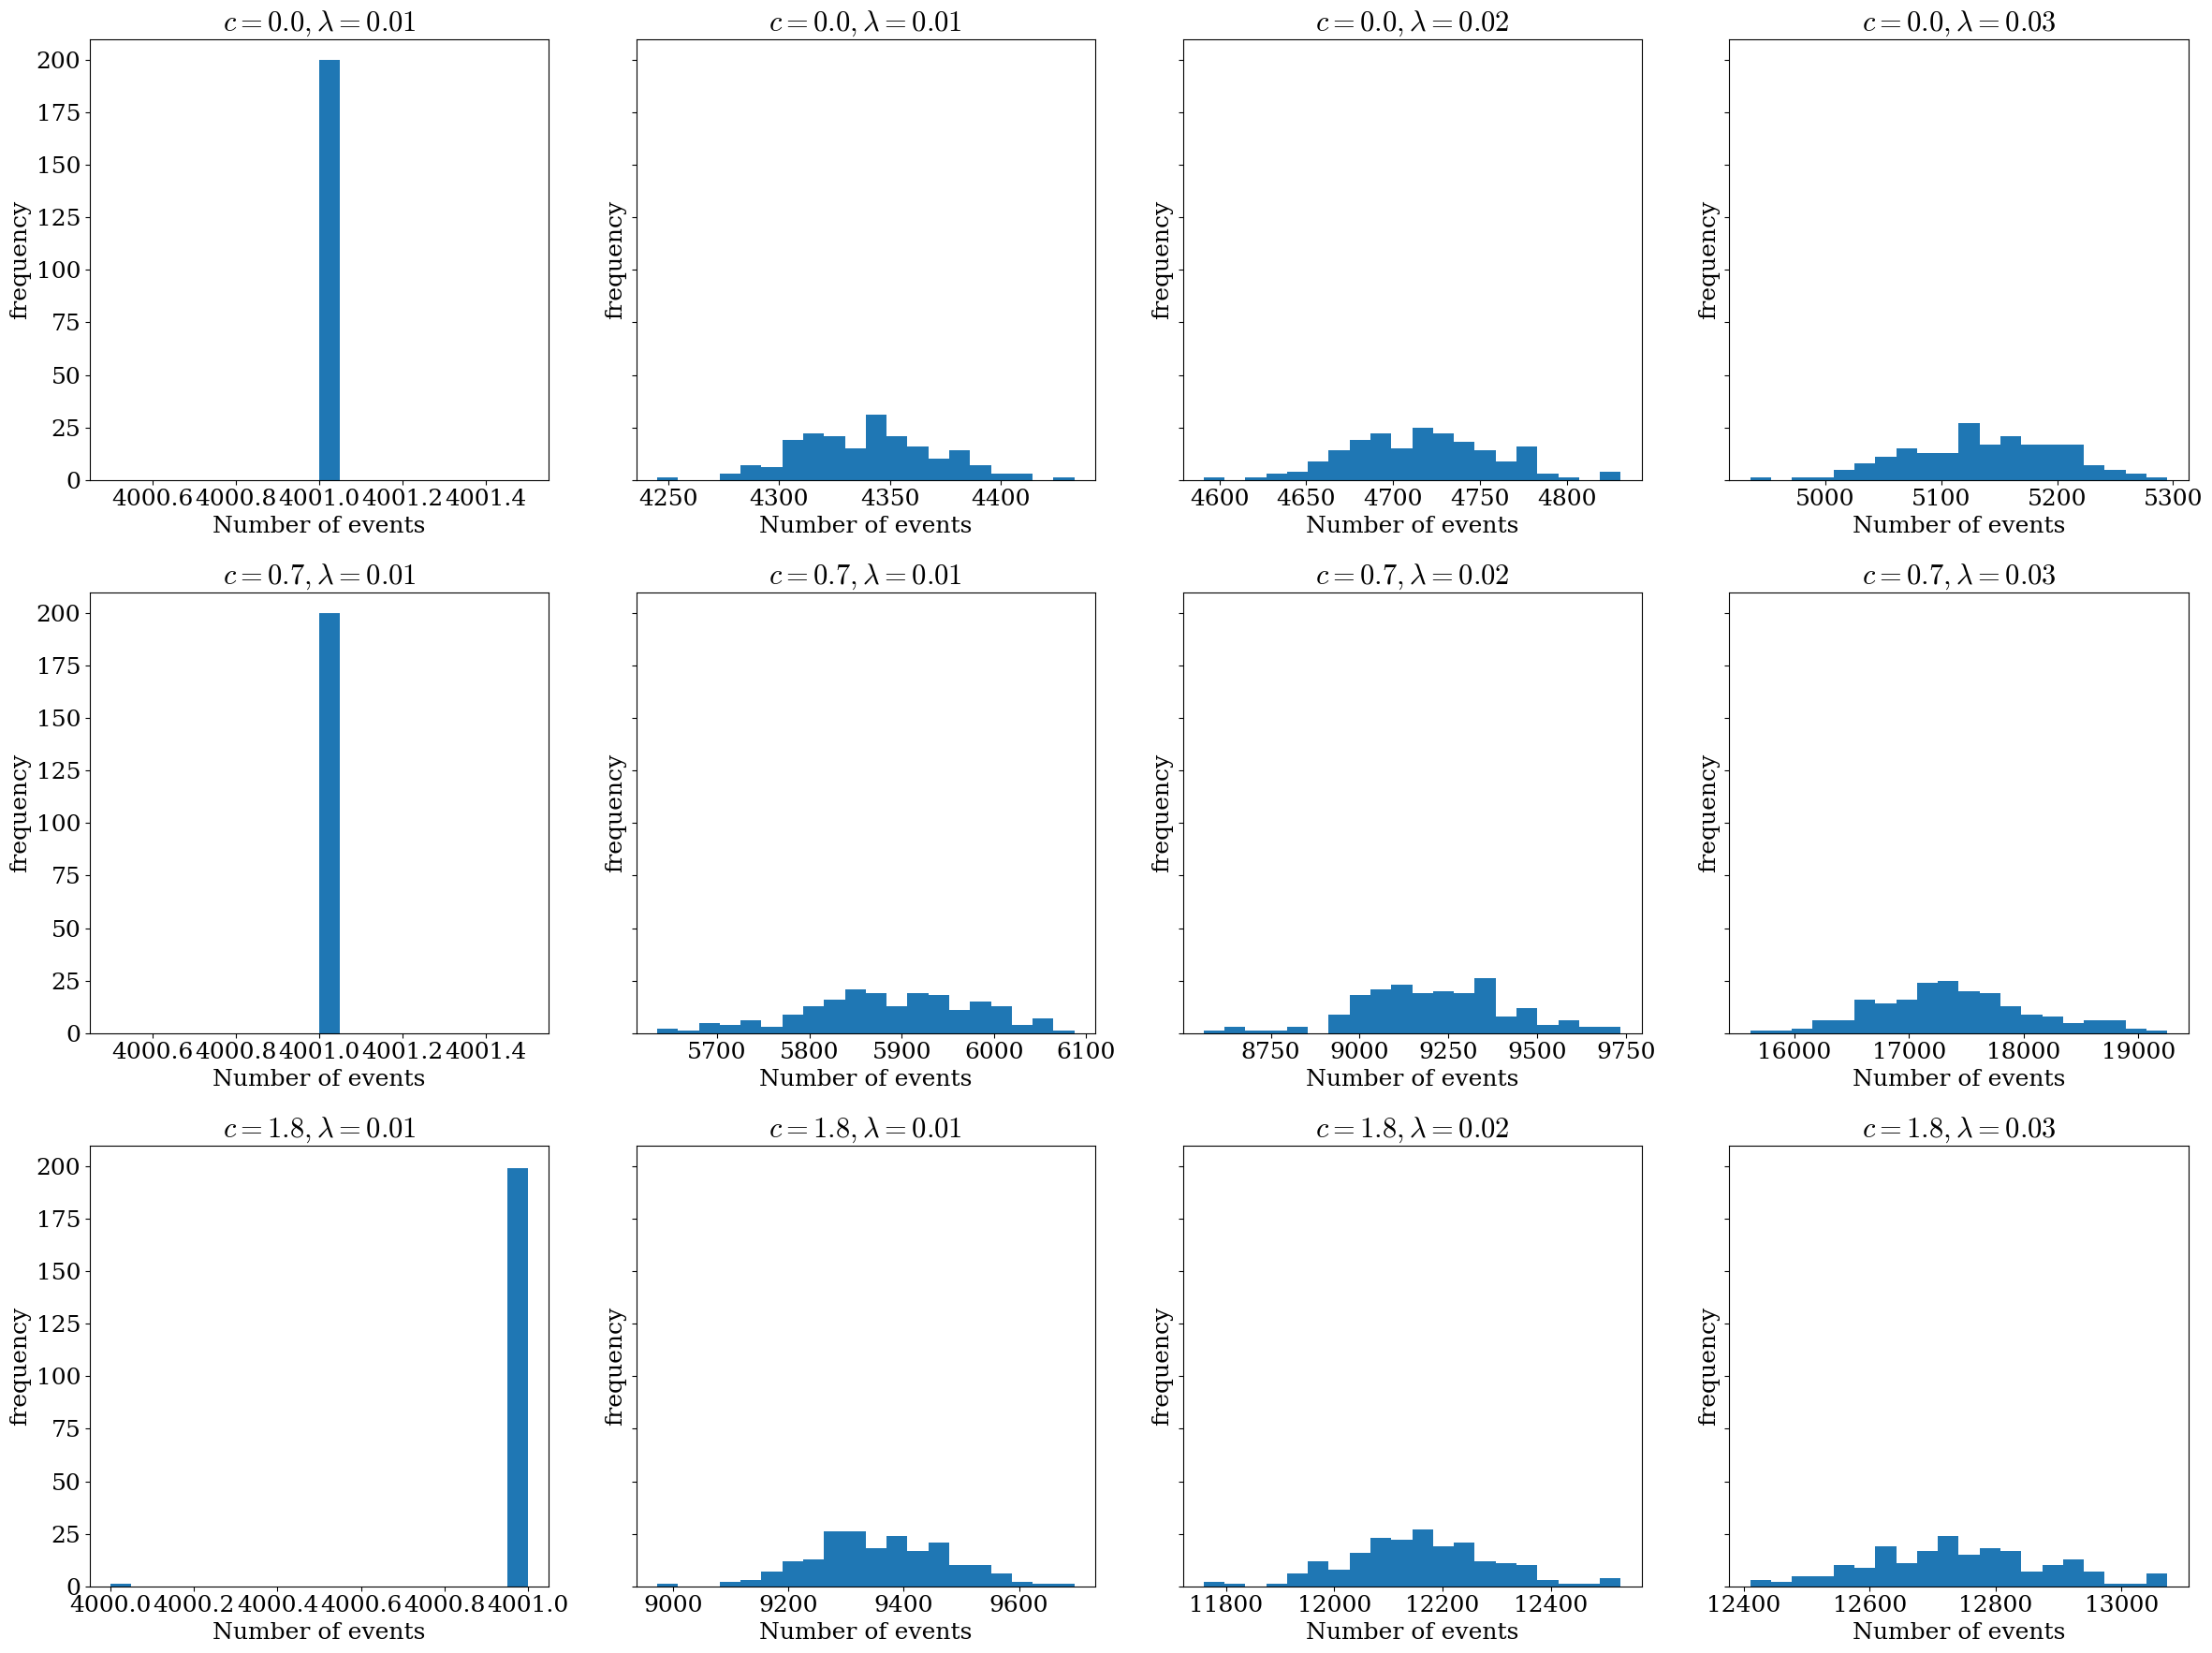

In [5]:
lamb_idx_list = [2, 3, 4, 5]

fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)), sharey=True)

for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        lamb = lamb_values[lamb_idx]
        event_nums = np.zeros(len(times_all[c_idx, l_idx, :]))
        for itr_idx in range(len(times_all[c_idx, l_idx, :])):
            event_nums[itr_idx] = len(times_all[c_idx, l_idx, itr_idx])
        axes[c_idx, l_idx].hist(event_nums, bins=20, color=colors[0])
        axes[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes[c_idx, l_idx].set_xlabel("Number of events")
        axes[c_idx, l_idx].set_ylabel("frequency")

fig.tight_layout()

plt.show()

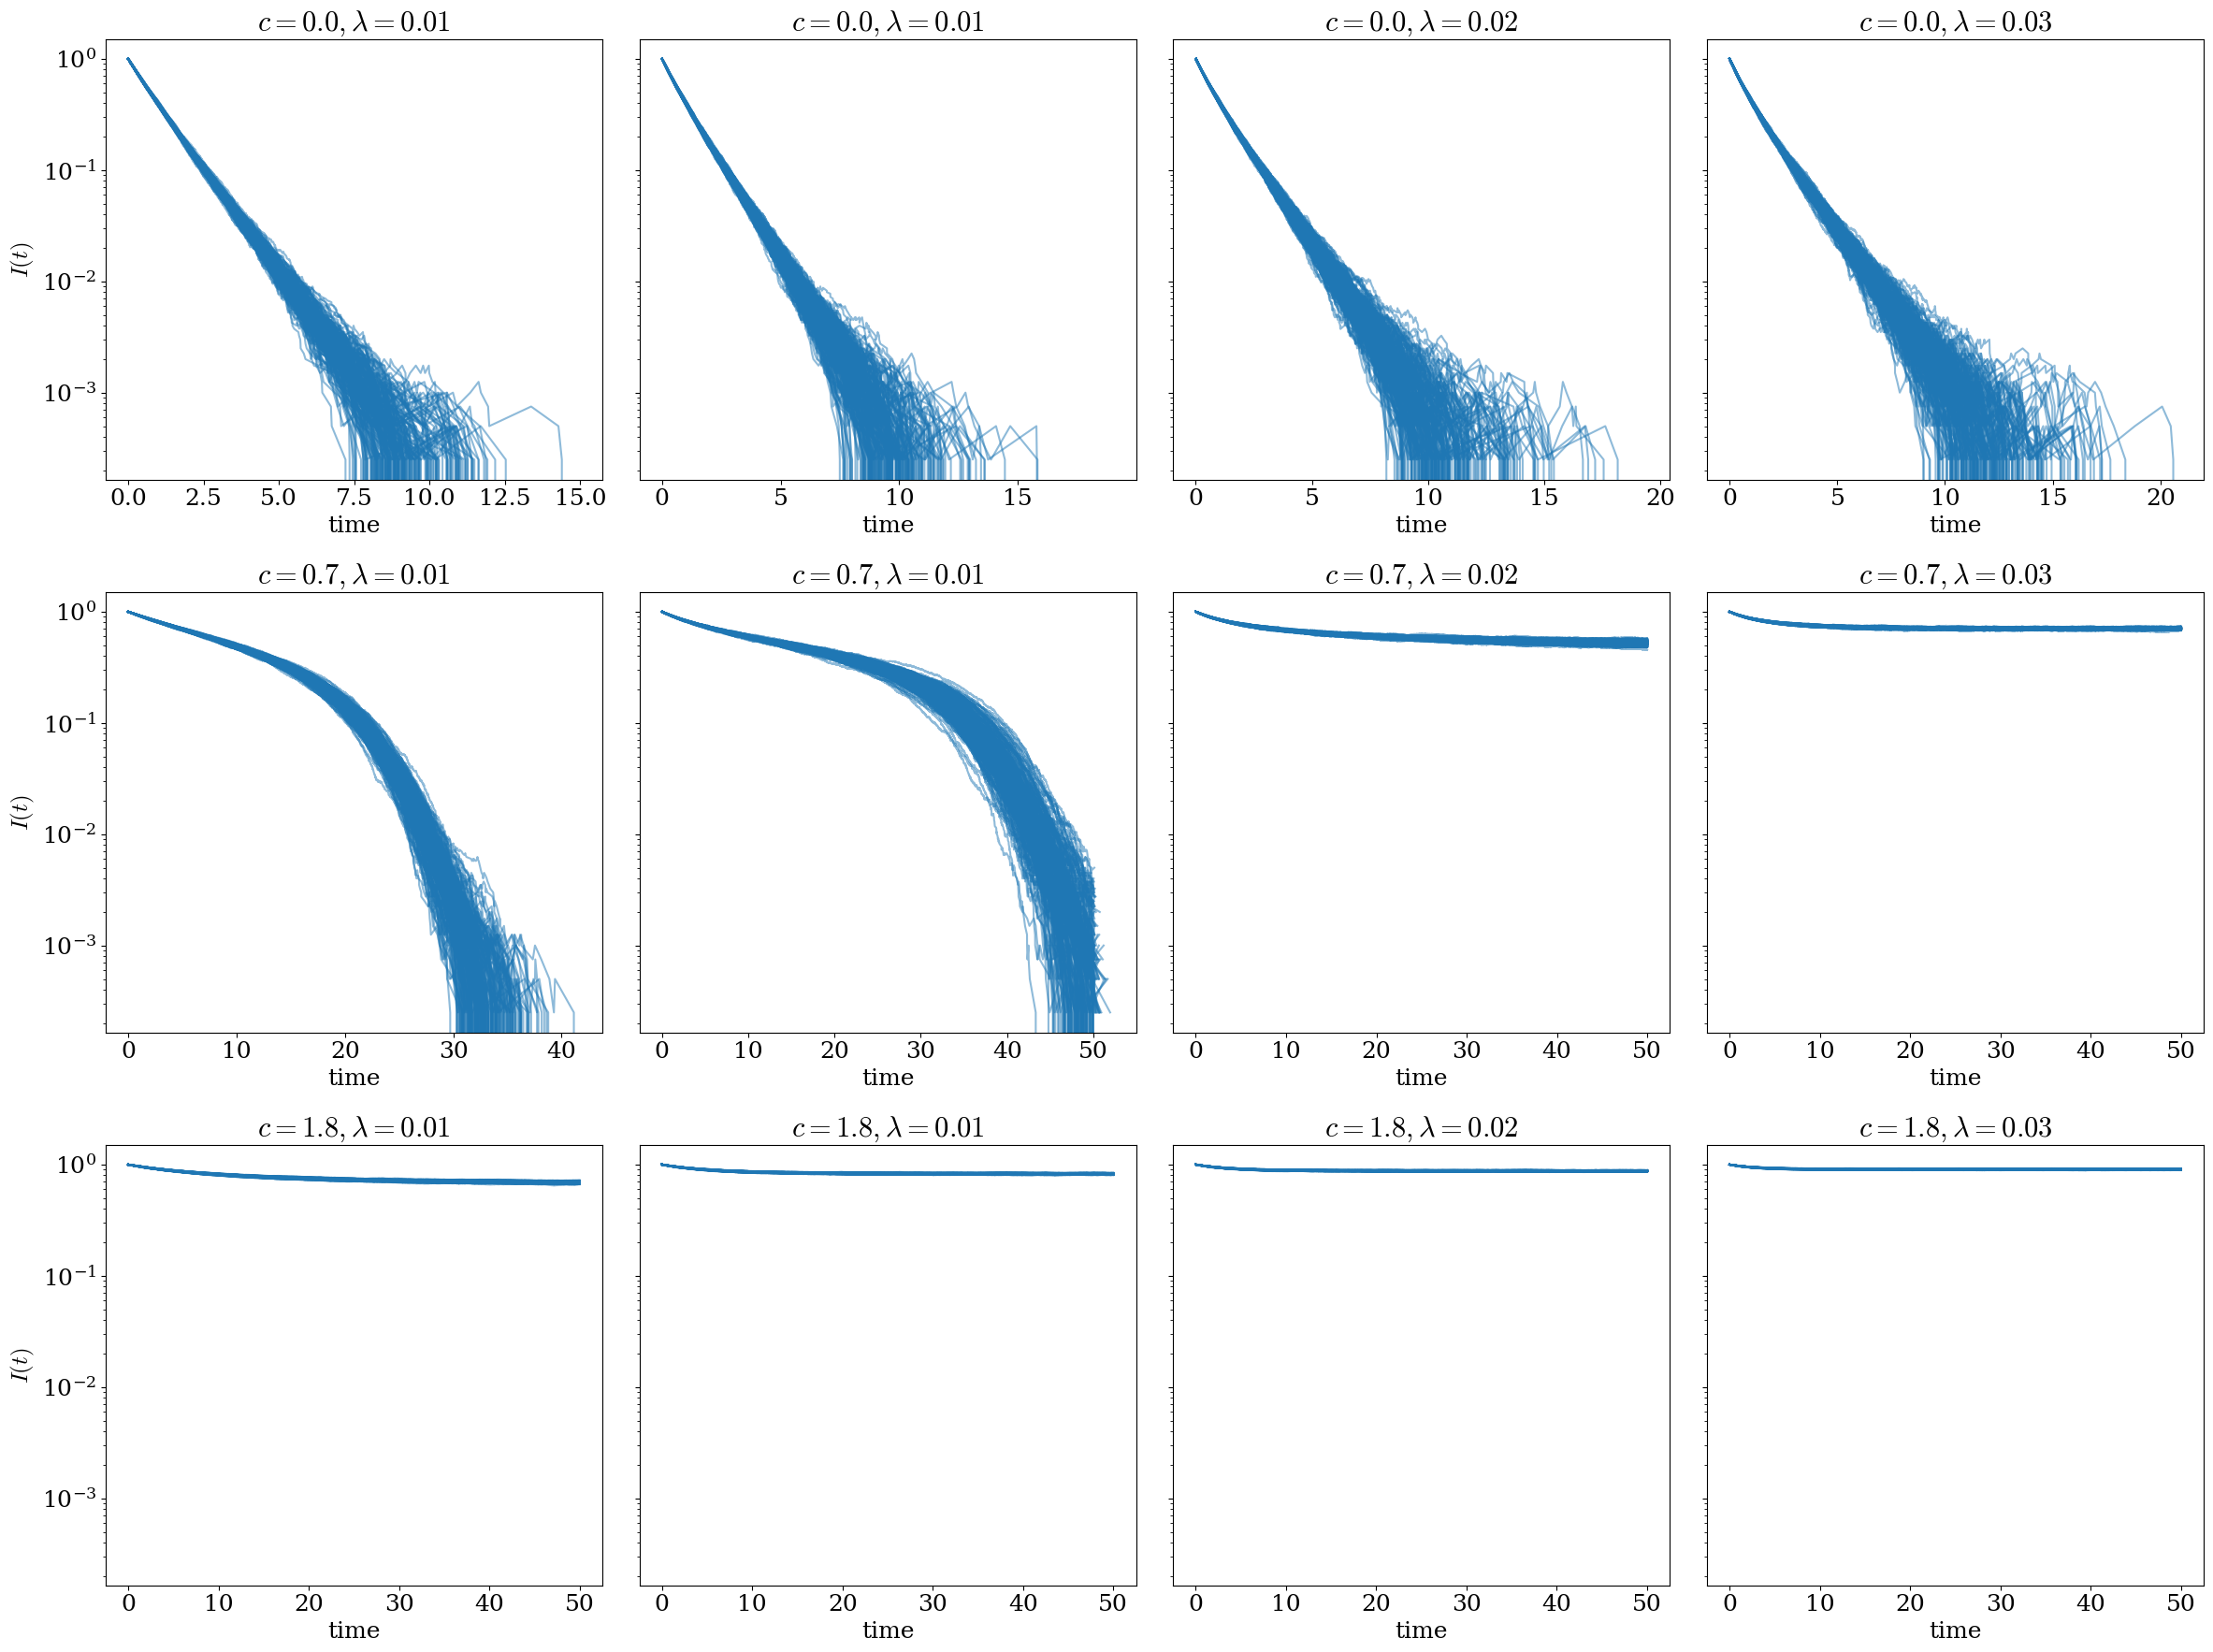

In [6]:
fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)), sharey=True)

for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        v_num = 0
        lamb = lamb_values[lamb_idx]
        for itr_idx in range(total_itr):
            I = I_all[c_idx, lamb_idx, itr_idx]
            t = times_all[c_idx, lamb_idx, itr_idx]
            if len(t) > 0:
                axes[c_idx, l_idx].plot(t, I/N, color=colors[0], alpha=0.5)

        axes[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes[c_idx, l_idx].set_xlabel("time")
        axes[c_idx, l_idx].set_yscale("log")
        # axes[c_idx, l_idx].set_xlim(0, 2.0)
        if l_idx == 0:
            axes[c_idx, l_idx].set_ylabel(r"$I(t)$")

fig.tight_layout()

plt.show()


In [7]:
threshold = 0

last_I = np.zeros((len(c_list), len(lamb_values), total_itr))
valid_last_I = np.zeros((len(c_list), len(lamb_values)))
valid_num = np.zeros((len(c_list), len(lamb_values)))
for c_idx in range(len(c_list)):
    for lamb_idx in range(len(lamb_values)):
        valid = []
        non_valid = []
        for itr_idx in range(len(I_all[c_idx, lamb_idx])):
            last_I[c_idx, lamb_idx, itr_idx] = I_all[c_idx, lamb_idx, itr_idx][-1]
            if last_I[c_idx, lamb_idx, itr_idx] > threshold:
                valid.append(last_I[c_idx, lamb_idx, itr_idx])
                valid_num[c_idx, lamb_idx] += 1
            else:
                non_valid.append(last_I[c_idx, lamb_idx, itr_idx])
        if len(valid) > 0:
            valid_last_I[c_idx, lamb_idx] = np.mean(valid)
        else:
            valid_last_I[c_idx, lamb_idx] = np.mean(non_valid)


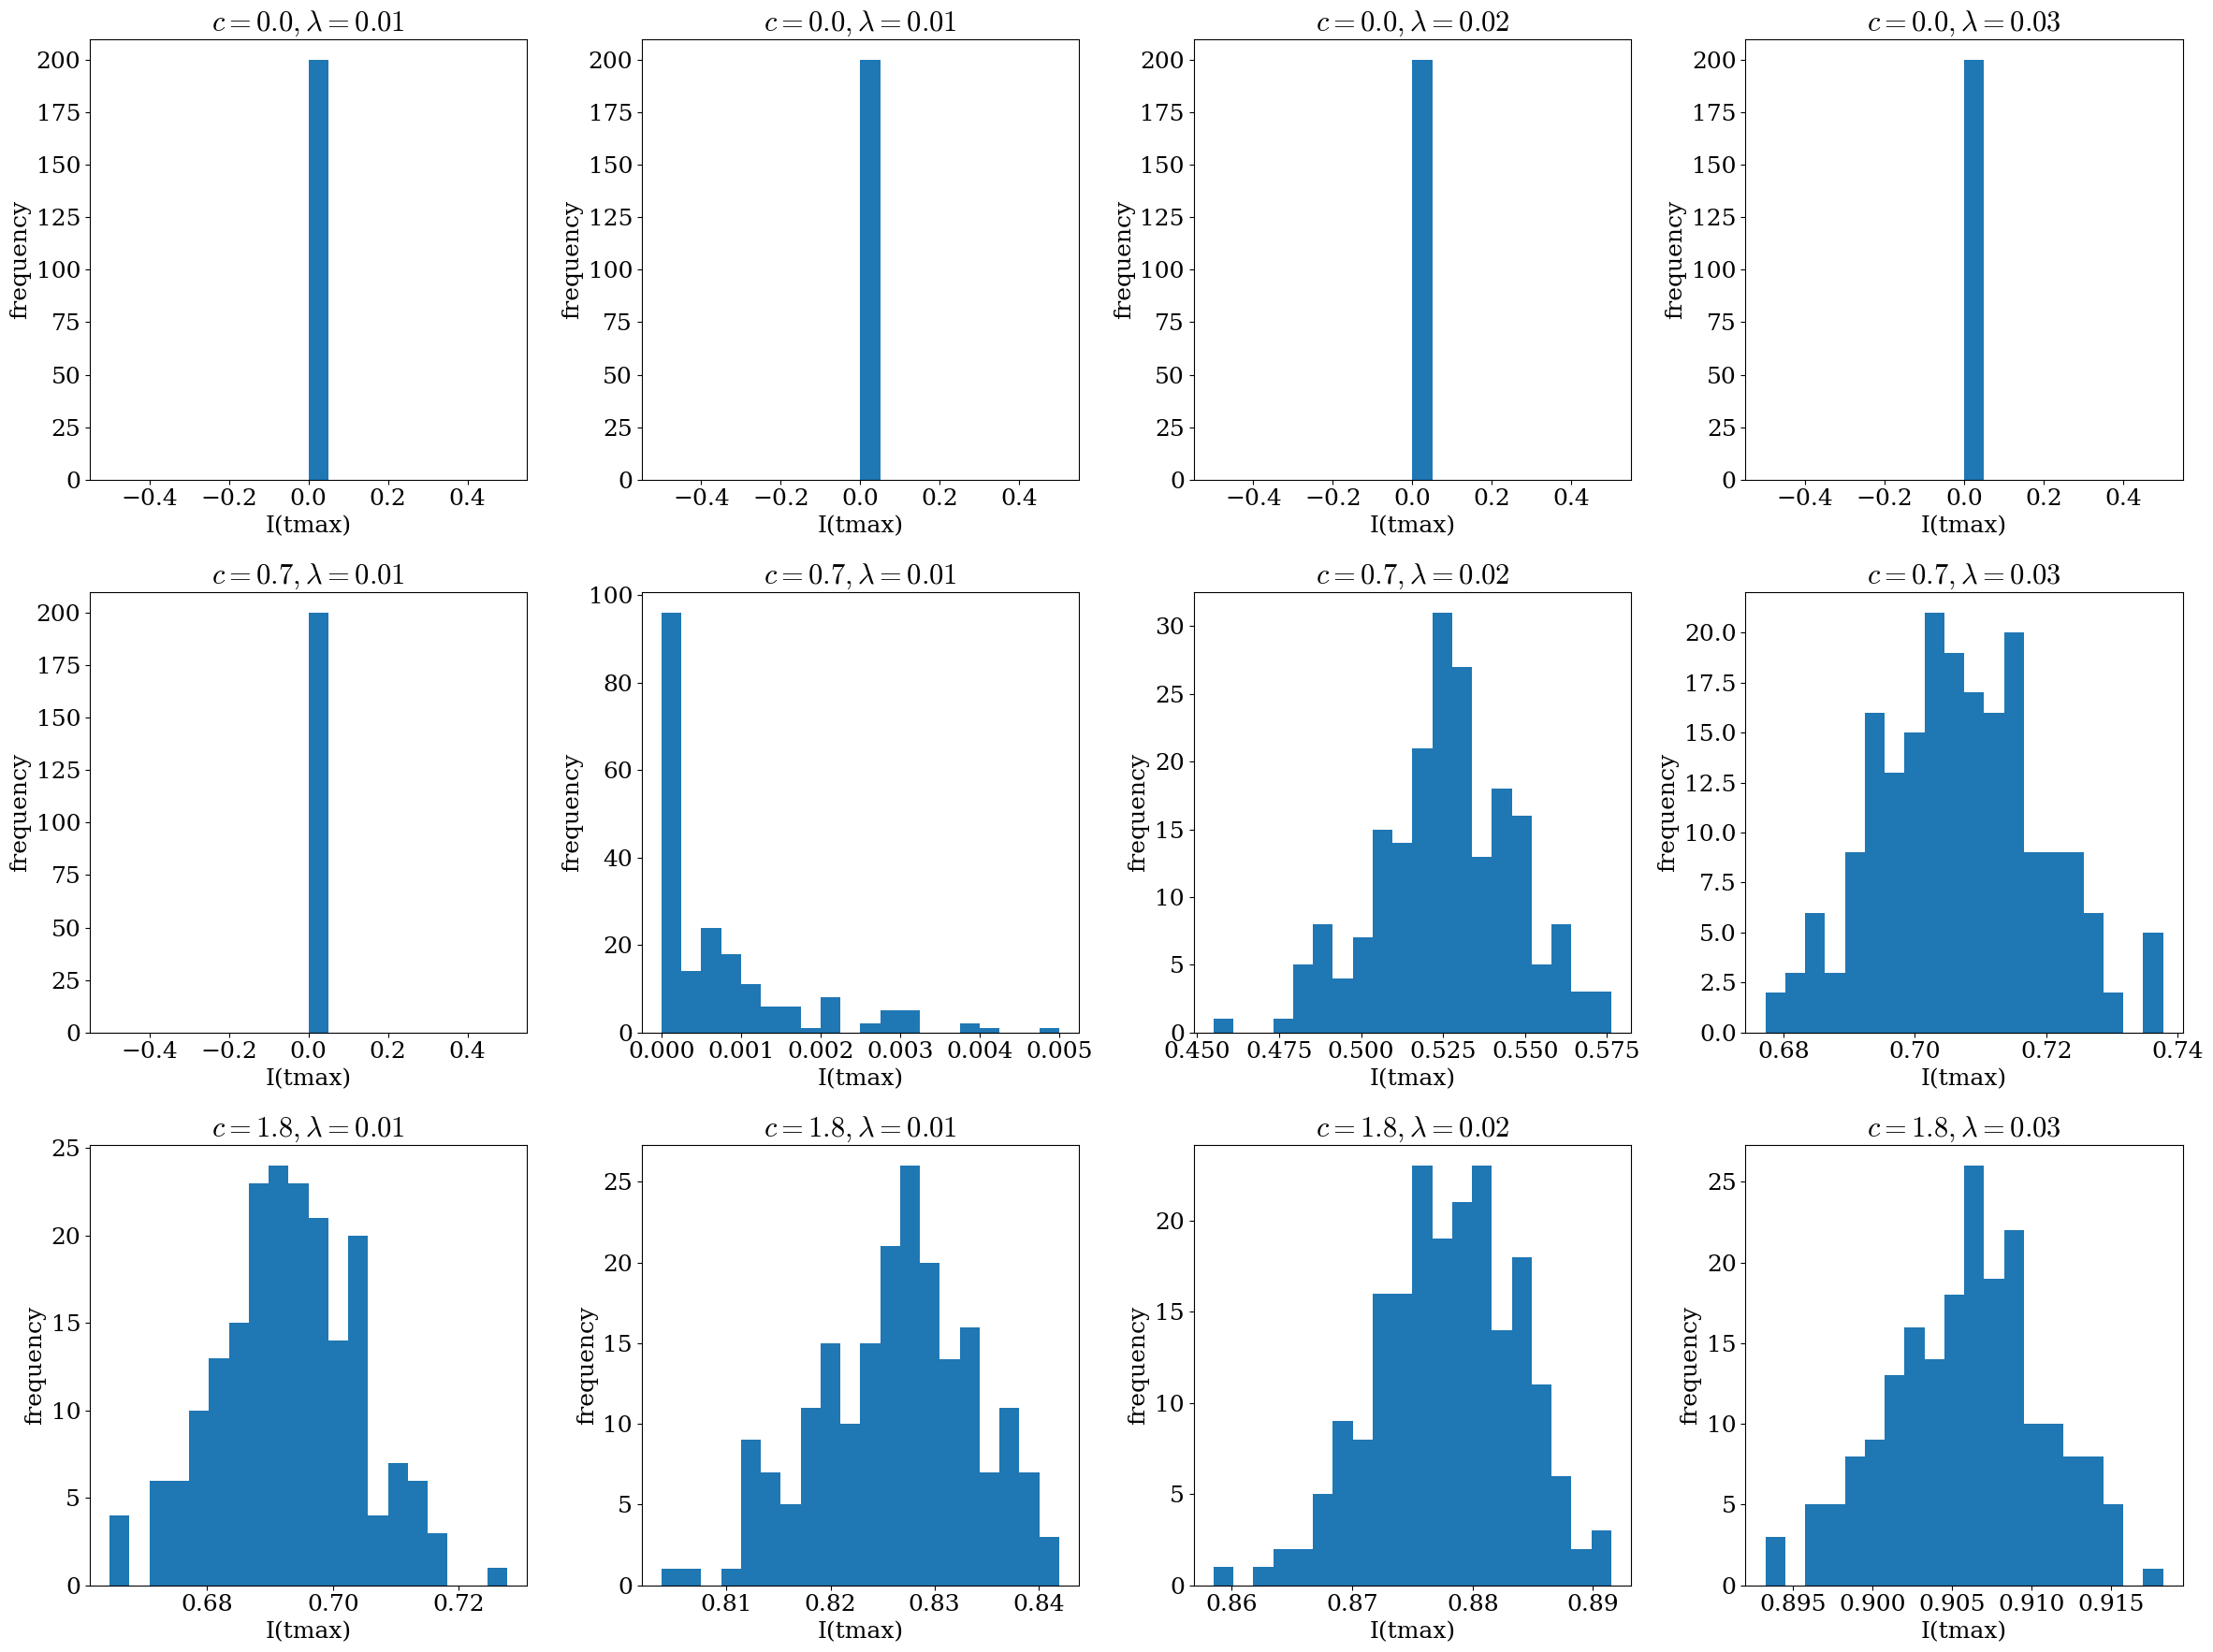

In [8]:
fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)))

for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        lamb = lamb_values[lamb_idx]
        axes[c_idx, l_idx].hist(last_I[c_idx, lamb_idx, :]/N, bins=20)
        axes[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes[c_idx, l_idx].set_xlabel("I(tmax)")
        axes[c_idx, l_idx].set_ylabel("frequency")

fig.tight_layout()

plt.show()

## 理論値とシミュレーションの比較

In [9]:
kappa = 2.5 # 冪分布の指数

network_type = "RR"

theta_all = np.zeros((len(c_list), len(lamb_values)))

for cidx, c in enumerate(c_list):
    theta_results = []

    # 各lambdaについてニュートン法でThetaを解く
    for lamb in lamb_values:
        if network_type == "RR":
            # 次数のリスト
            deg_list = [k_ave]
            pk = np.array([1.0])

        elif network_type == "ER":
            # 次数のリスト (ポアソン分布が意味を持つ範囲)
            # 平均の3倍+10程度あれば十分
            deg_list = np.arange(0, int(k_ave * 3) + 10)

            # 次数分布 p(k) を計算 (ポアソン分布)
            pk = scipy.stats.poisson.pmf(deg_list, k_ave)

        elif network_type == "SF":
            deg_list = np.arange(1, 1000)

            C = (2 - kappa) * k_ave
            pk = C * deg_list ** (- kappa)

        else:
            raise ValueError(f"Invalid network type: {network_type}")

        # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
        # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
        solution = newton_method(deg_list, pk, lamb, gamma, c=c)
        
        # 物理的に意味のある解は Theta >= 0
        if solution < 0:
            solution = 0
            
        theta_results.append(solution)
        # print(f"{lamb:.4f}, {solution:.8f}")

    theta_all[cidx, :] = theta_results

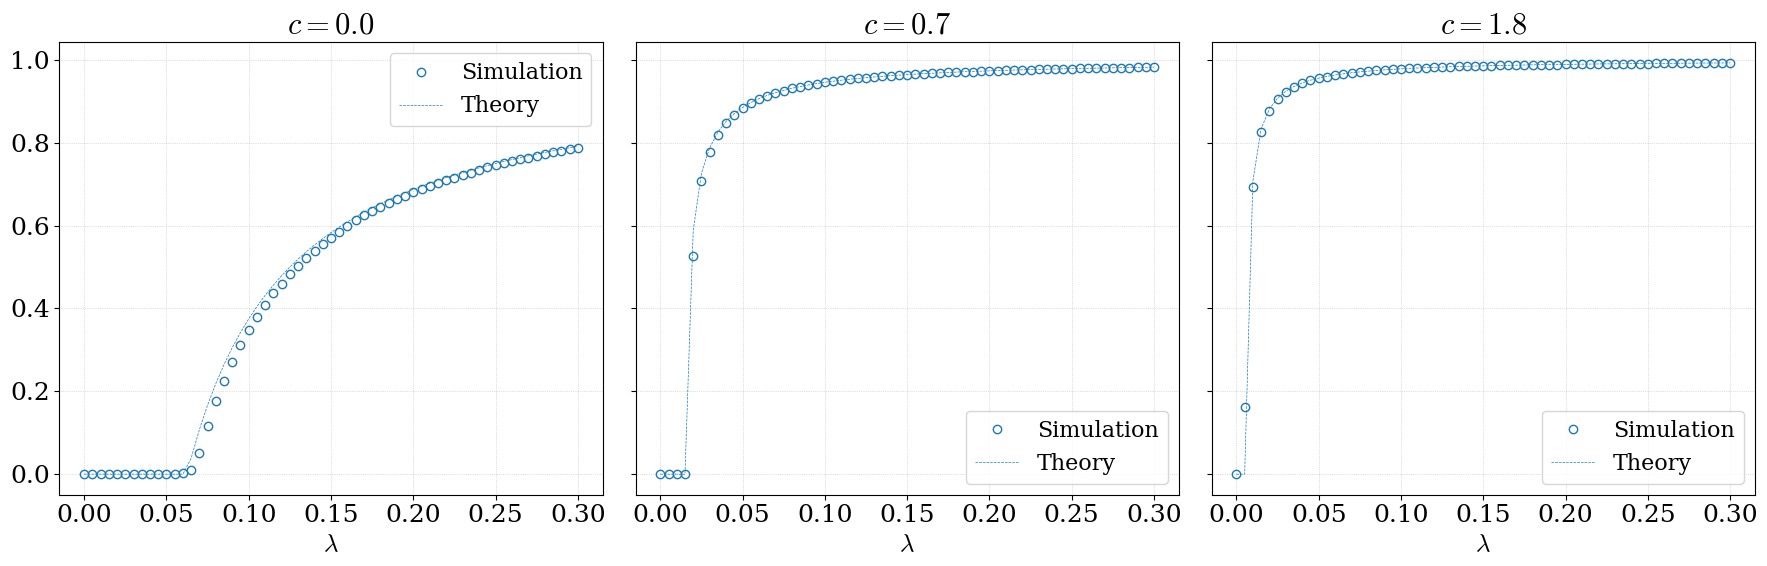

: 

In [ ]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True)

for c_idx, c in enumerate(c_list):
    to_Is = np.zeros(len(lamb_values))
    for lamb_idx, lamb in enumerate(lamb_values):
        to_I = theta_to_I(deg_list, pk, lamb, gamma, theta_all[c_idx, lamb_idx], c=c)
        to_Is[lamb_idx] = to_I
    valid_mean_I = valid_last_I[c_idx, :]
    axes[c_idx].plot(lamb_values, valid_mean_I/N, label="Simulation", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
    axes[c_idx].plot(lamb_values, to_Is, color=colors[0], label="Theory", linestyle="--", linewidth=0.5)
    # axes[c_idx].plot(lamb_values, theta_all[c_idx, :], color=colors[0], label="Theory", linestyle="--", linewidth=0.5)
    axes[c_idx].legend()
    axes[c_idx].grid(True, linestyle=":", alpha=0.5)
    axes[c_idx].set_title(rf"$c={c}$")
    axes[c_idx].set_xlabel(r"$\lambda$")

fig.tight_layout()

plt.show()